In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path


BASE = Path(r"C:\Users\chotu\Downloads\Bluestock_Mf_Capstone")

RAW = BASE / "data" / "raw"
PROCESSED = BASE / "data" / "processed"
CHARTS = BASE / "reports" / "charts"


print(RAW)

C:\Users\chotu\Downloads\Bluestock_Mf_Capstone\data\raw


In [17]:
nav = pd.read_csv(
    RAW / "02_nav_history.csv"
)

transactions = pd.read_csv(
    RAW / "08_investor_transactions.csv"
)

performance = pd.read_csv(
    RAW / "07_scheme_performance.csv"
)

holdings = pd.read_csv(
    RAW / "09_portfolio_holdings.csv"
)

print("Loaded")

Loaded


In [18]:
print(nav.columns)

print(transactions.columns)

print(performance.columns)

print(holdings.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [19]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [20]:
var_cvar = (
    nav.groupby("amfi_code")["daily_return"]
    .apply(
        lambda x: pd.Series({
            "VaR_95":
            np.percentile(
                x.dropna(),5
            ),

            "CVaR_95":
            x[
                x <= np.percentile(
                    x.dropna(),5
                )
            ].mean()
        })
    )
    .unstack()
)


var_cvar.head()

,VaR_95,CVaR_95
amfi_code,,
100016,-0.014364,-0.018060
100025,-0.003793,-0.004994
100033,-0.019034,-0.023456
101206,-0.013282,-0.017439
101207,-0.026021,-0.032459


In [21]:
var_cvar.to_csv(
    PROCESSED/"var_cvar_report.csv"
)

print("VaR saved")

VaR saved


In [22]:
nav["rolling_sharpe"] = (
    nav.groupby("amfi_code")
    ["daily_return"]
    .transform(
        lambda x:
        (
            x.rolling(90).mean()
            /
            x.rolling(90).std()
        )
        *
        np.sqrt(252)
    )
)

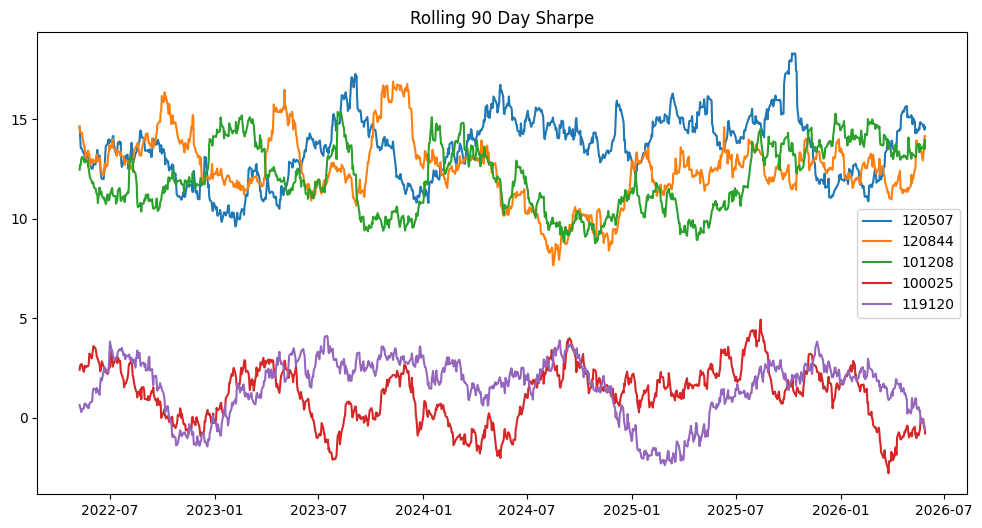

In [23]:
top5 = (
    performance
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)
)


plt.figure(figsize=(12,6))


for code in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"]==code
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(code)
    )


plt.legend()

plt.title(
    "Rolling 90 Day Sharpe"
)


plt.savefig(
    CHARTS/"rolling_sharpe_chart.png"
)


plt.show()

In [24]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)


transactions["cohort_year"] = (
    transactions
    .groupby("investor_id")
    ["transaction_date"]
    .transform("min")
    .dt.year
)

In [25]:
cohort = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_sip_amount =
        ("amount_inr","mean"),

        total_invested =
        ("amount_inr","sum")
    )
)

cohort

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [26]:
top_fund = (
    transactions
    .groupby(
        ["cohort_year","amfi_code"]
    )
    ["amount_inr"]
    .sum()
    .reset_index()
)


top_fund = (
    top_fund
    .sort_values(
        "amount_inr",
        ascending=False
    )
    .drop_duplicates(
        "cohort_year"
    )
)


top_fund

,cohort_year,amfi_code,amount_inr
6,2024,102885,100126141
62,2025,119599,1478507


In [27]:
sip = transactions[
    transactions["transaction_type"]
    .str.contains(
        "sip",
        case=False,
        na=False
    )
]


sip = sip.sort_values(
    ["investor_id","transaction_date"]
)


sip["gap_days"] = (
    sip.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

In [28]:
continuity = (
    sip.groupby("investor_id")
    .agg(
        sip_count =
        ("transaction_date","count"),

        avg_gap =
        ("gap_days","mean")
    )
)


continuity = continuity[
    continuity["sip_count"]>=6
]


continuity["status"] = np.where(
    continuity["avg_gap"]>35,
    "At Risk",
    "Healthy"
)


continuity.head()

,sip_count,avg_gap,status
investor_id,,,
INV000004,6,85.400000,At Risk
INV000008,6,70.400000,At Risk
INV000010,6,64.800000,At Risk
INV000011,7,40.166667,At Risk
INV000012,8,57.000000,At Risk


In [29]:
def recommend_funds(risk):

    return (
        performance[
            performance["risk_grade"]
            == risk
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
        [
        [
        "scheme_name",
        "fund_house",
        "sharpe_ratio",
        "risk_grade"
        ]
        ]
    )

In [30]:
recommend_funds("High")

,scheme_name,fund_house,sharpe_ratio,risk_grade
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,0.96,High
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,0.95,High
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,0.90,High


In [31]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [32]:
holdings["weight_sq"] = (
    holdings["weight_pct"]/100
)**2


hhi = (
    holdings
    .groupby("amfi_code")
    ["weight_sq"]
    .sum()
    .reset_index()
)


hhi.columns=[
    "amfi_code",
    "HHI"
]


hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709
